<a href="https://colab.research.google.com/github/sjsu-cs122-s26/outstanding-heartdisease-analysis/blob/main/notebooks/medical_history.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/data/heart_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#Medical History
## Overview
This section will review the set of columns that are Binary questions highlighting medical conditions that exist alongside heart disease. This section will determine which conditions have correlation with developing heart disease.

Questions:
1. **Body System Correlation** Which body system's health is the strongest predictor of heart disease?
2. **Multi-Condition Risk** How does the rate of heart disease get affected by the total number of medical conditions?
3. **Total Picture** Which medical condition has the most impact individually, how is this displayed in different demographics?

#Data Setup

In [80]:
# Define the 8 columns and target
conditions = [
    'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
    'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes'
]
target = 'HadHeartDisease'

demo_cols = ['AgeCategory', 'Sex', 'RaceEthnicityCategory']
analysis_df = data[conditions + [target] + demo_cols].copy()

# Clean up HadDiabetes column
diabetes_cleanup = {
    'Yes': 'Yes',
    'No': 'No',
    'No, pre-diabetes or borderline diabetes': 'No',
    'Yes, but only during pregnancy (female)': 'Yes',
    'Unknown': np.nan
}
analysis_df['HadDiabetes'] = analysis_df['HadDiabetes'].map(diabetes_cleanup)

# Fix race names for graph
race_map = {
    'White only, Non-Hispanic': 'White',
    'Black only, Non-Hispanic': 'Black',
    'Hispanic': 'Hispanic',
    'Multiracial, Non-Hispanic': 'Multiracial',
    'Other race only, Non-Hispanic': 'Other'
}
analysis_df['Race'] = analysis_df['RaceEthnicityCategory'].map(race_map)
# Mapping function
def map_columns(val):
    val = str(val).lower().strip()
    if val == 'yes':
        return 1
    if val == 'no':
        return 0
    return 0

# Apply mapping
for col in conditions:
    analysis_df[col] = analysis_df[col].apply(map_columns)

analysis_df.head()

,HadStroke,HadAsthma,HadSkinCancer,HadCOPD,HadDepressiveDisorder,HadKidneyDisease,HadArthritis,HadDiabetes,HadHeartDisease,AgeCategory,Sex,RaceEthnicityCategory,Race
0,0,0,0,0,0,0,0,1,0,Age 80 or older,Female,"White only, Non-Hispanic",White
1,0,0,1,0,0,0,0,0,0,Age 80 or older,Female,"White only, Non-Hispanic",White
2,0,0,1,0,0,0,0,0,0,Age 55 to 59,Female,"White only, Non-Hispanic",White
3,0,1,0,0,0,0,1,0,0,Unknown,Female,"White only, Non-Hispanic",White
4,0,0,0,0,0,0,0,0,0,Age 40 to 44,Female,"White only, Non-Hispanic",White


# 1. Body System Correlation
## Which body system's health is the strongest predictor of heart disease?

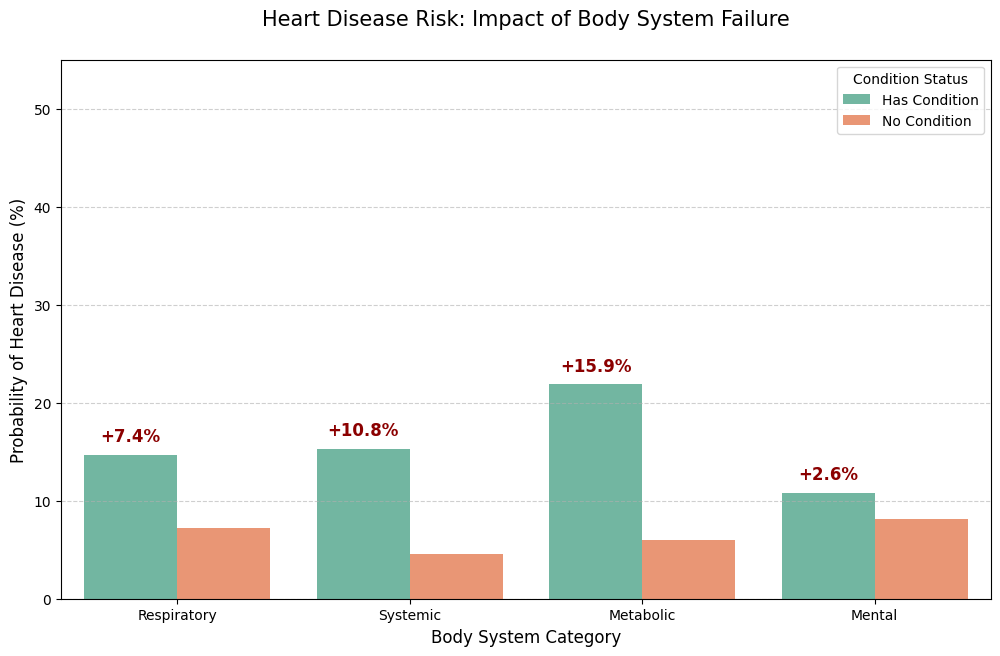

In [81]:
# Define the 4 subcategories;
respiratory_list = ['HadAsthma', 'HadCOPD']
systemic_list = ['HadSkinCancer', 'HadKidneyDisease', 'HadArthritis']
metabolic_list = ['HadStroke', 'HadDiabetes']
mental_list = ['HadDepressiveDisorder']

# Create the subcategory columns
# If a person has atleast one condition they are added
analysis_df['Respiratory'] = analysis_df[respiratory_list].max(axis=1)
analysis_df['Systemic'] = analysis_df[systemic_list].max(axis=1)
analysis_df['Metabolic'] = analysis_df[metabolic_list].max(axis=1)
analysis_df['Mental'] = analysis_df[mental_list].max(axis=1)

# Define target
target = 'HadHeartDisease'

# Set the 4 categories
categories = ['Respiratory', 'Systemic', 'Metabolic', 'Mental']
comparison_data = []
differences = {}

for cat in categories:

    # Calculate the average heart disease rate for people with the condition
    risk_yes = analysis_df[analysis_df[cat] == 1]['HadHeartDisease'].mean() * 100
    # Calculate the average heart disease rate for people without the condition
    risk_no = analysis_df[analysis_df[cat] == 0]['HadHeartDisease'].mean() * 100

    # Format for bar plot
    comparison_data.append({'System': cat, 'Condition Status': 'Has Condition', 'HD_Probability': risk_yes})
    comparison_data.append({'System': cat, 'Condition Status': 'No Condition', 'HD_Probability': risk_no})

    # Store the difference for labeling
    differences[cat] = risk_yes - risk_no

# Convert to DataFrame
comp_df = pd.DataFrame(comparison_data)

#Plotting
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=comp_df, x='System', y='HD_Probability', hue='Condition Status', palette='Set2')

# Adding the difference labels above each bar
# Loop through the differences list which stores the difference between
# people who have the condition vs people who dont
for i, cat in enumerate(categories):
    diff = differences[cat]

    # Find the hieght of the condition bar
    y_val = comp_df[(comp_df['System'] == cat) & (comp_df['Condition Status'] == 'Has Condition')]['HD_Probability'].values[0]

    # Place thte text above the risk_yes bar
    plt.text(i - 0.2, y_val + 1, f"+{diff:.1f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

# Formatting
plt.title('Heart Disease Risk: Impact of Body System Failure', fontsize=15, pad=25)
plt.ylabel('Probability of Heart Disease (%)', fontsize=12)
plt.xlabel('Body System Category', fontsize=12)
plt.ylim(0, 55)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Condition Status', loc='upper right')

plt.show()

# 2. Multi-Condition Risk
## How does the rate of heart disease get affected by the total number of medical conditions?

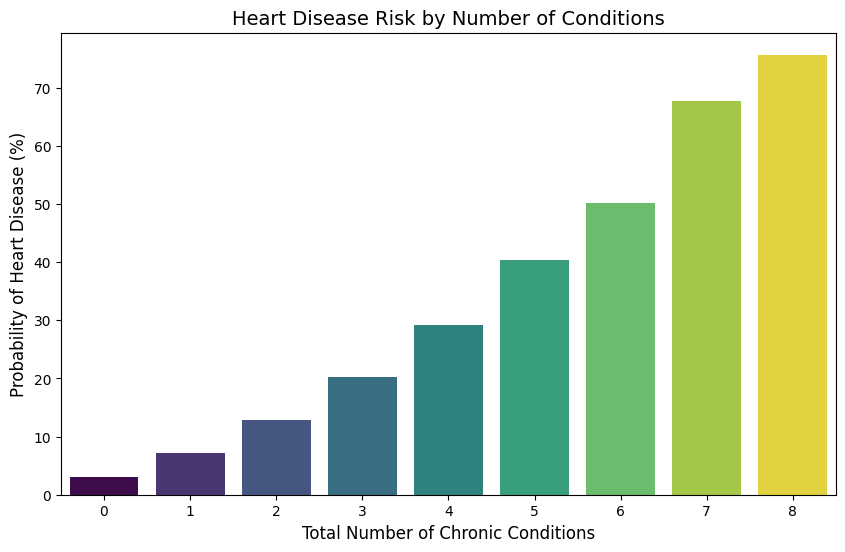

In [82]:
# Calculate the Condition Count
# Sums the amount of medical conditions a singular row contains
analysis_df['ConditionCount'] = analysis_df[conditions].sum(axis=1)

# Calculate the average heart disease rate per count
heartdisease_risk = analysis_df.groupby('ConditionCount')['HadHeartDisease'].mean()

# Plot the "Staircase"
plt.figure(figsize=(10, 6))
sns.barplot(
    x = heartdisease_risk .index,
    y = heartdisease_risk .values * 100,
    hue = heartdisease_risk .index,
    palette = 'viridis',
    legend = False
)

# Title and labels
plt.title('Heart Disease Risk by Number of Conditions', fontsize=14)
plt.xlabel('Total Number of Chronic Conditions', fontsize=12)
plt.ylabel('Probability of Heart Disease (%)', fontsize=12)
plt.show()

In [83]:
#  Calculate the percentage point jumps between each level
risk_diffs = heartdisease_risk.diff() * 100

# Calculate the risk multiplier (how much more likely from the previous step)
risk_multipliers = heartdisease_risk / heartdisease_risk.shift(1)

# Create summary table
staircase_summary = pd.DataFrame({
    'Heart Disease Probability (%)': (heartdisease_risk * 100).round(2),
    'Jump (Percentage Points)': risk_diffs.round(2),
    'Risk Multiplier (vs Previous)': risk_multipliers.round(2)
})

print("Staircase Effect: Detailed Risk Data")
print(" ")
print(staircase_summary)

Staircase Effect: Detailed Risk Data
 
                Heart Disease Probability (%)  Jump (Percentage Points)  \
ConditionCount                                                            
0                                        3.07                       NaN   
1                                        7.13                      4.07   
2                                       12.93                      5.79   
3                                       20.30                      7.38   
4                                       29.19                      8.89   
5                                       40.32                     11.13   
6                                       50.22                      9.90   
7                                       67.69                     17.47   
8                                       75.68                      7.98   

                Risk Multiplier (vs Previous)  
ConditionCount                                 
0                                      

#3. Total Picture
##Which medical condition has the most impact individually, how is this displayed in different demographics?

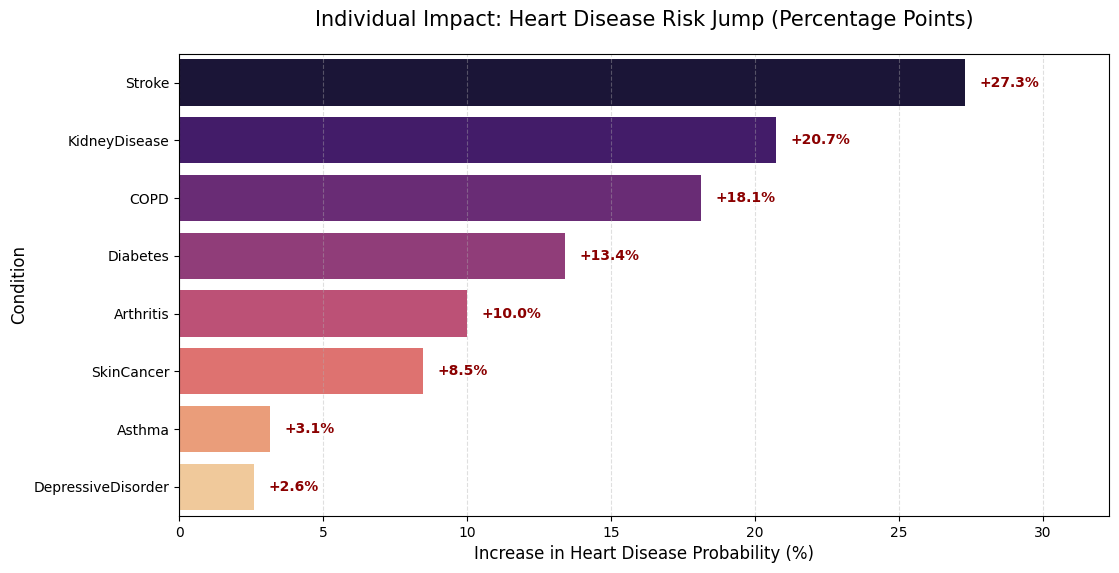

In [84]:
# Calculate the 'Risk Difference' for all 8 individual conditions
indiv_results = []

for col in conditions:
    # Heart disease rate for those with the condition
    risk_yes = analysis_df[analysis_df[col] == 1]['HadHeartDisease'].mean() * 100

    # Heart disease rate for those without the specific condition (the baseline)
    risk_no = analysis_df[analysis_df[col] == 0]['HadHeartDisease'].mean() * 100

    # The 'Risk Difference' is the subtraction of the two
    indiv_results.append({
        'Condition': col.replace('Had', ''),
        'Risk_Difference': risk_yes - risk_no
    })

# Convert to DataFrame and sort by the biggest jump
diff_df = pd.DataFrame(indiv_results).sort_values('Risk_Difference', ascending=False)

# Plotting
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=diff_df,
    x='Risk_Difference',
    y='Condition',
    hue='Condition',
    palette='magma',
    legend=False
)

# Add risk difference next to bars
for i, val in enumerate(diff_df['Risk_Difference']):
    plt.text(val + 0.5, i, f"+{val:.1f}%", va='center', fontweight='bold', color='darkred')

# Formatting
plt.title('Individual Impact: Heart Disease Risk Jump (Percentage Points)', fontsize=15, pad=20)
plt.xlabel('Increase in Heart Disease Probability (%)', fontsize=12)
plt.ylabel('Condition', fontsize=12)
plt.xlim(0, max(diff_df['Risk_Difference']) + 5)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

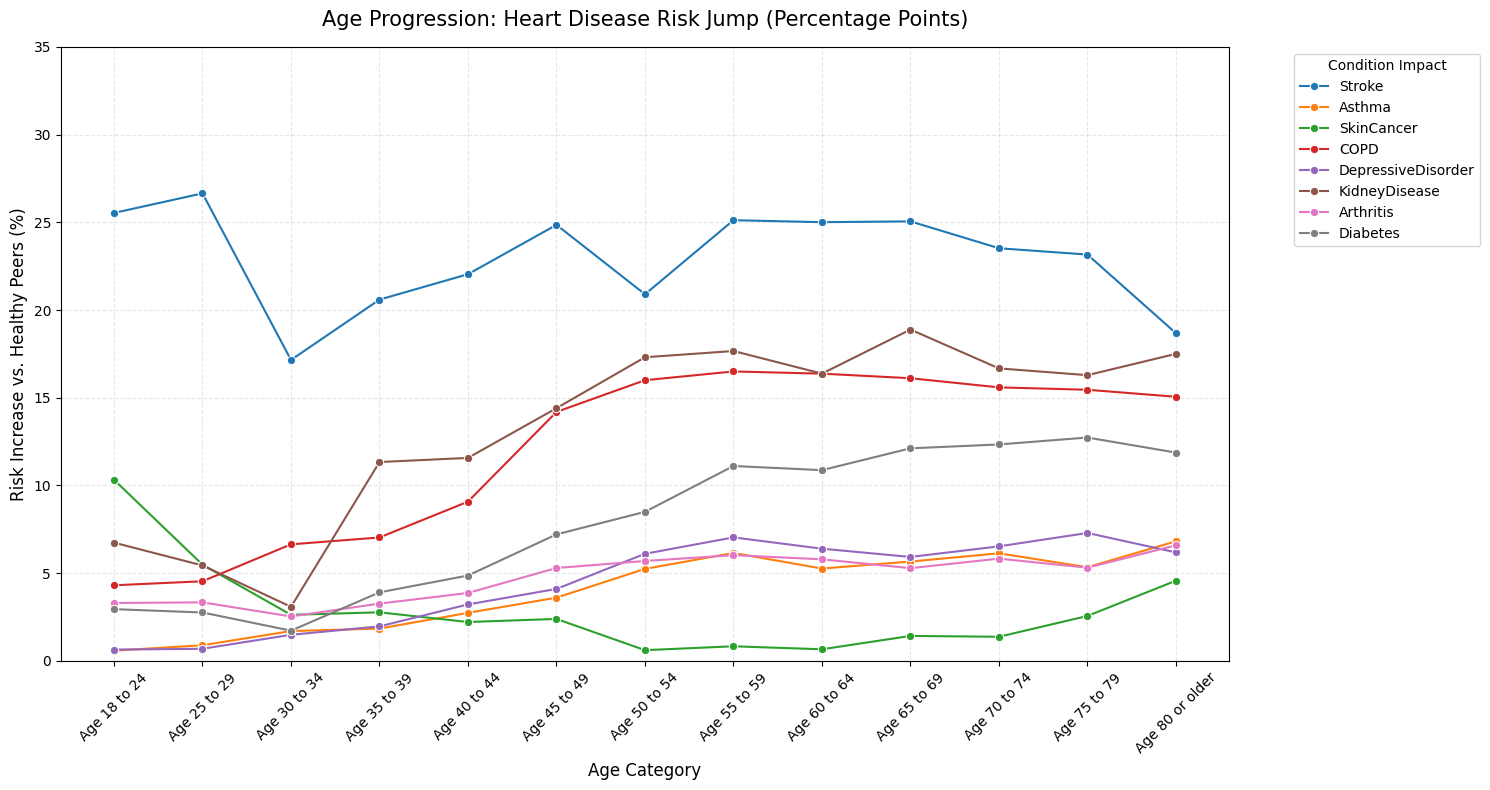

In [85]:
plt.figure(figsize=(15, 8))

age_order = [
    'Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39',
    'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59',
    'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
    'Age 80 or older'
]

for col in conditions:
    age_jumps = []
    for age in age_order:
        # Filter for the specific age group
        subset = analysis_df[analysis_df['AgeCategory'] == age]

        # Calculate Risk Jump: (Risk with condition) - (Risk without condition)
        risk_yes = subset[subset[col] == 1][target].mean() * 100
        risk_no = subset[subset[col] == 0][target].mean() * 100

        age_jumps.append(risk_yes - risk_no)

    sns.lineplot(x=age_order, y=age_jumps, marker='o', label=col.replace('Had',''))

plt.title('Age Progression: Heart Disease Risk Jump (Percentage Points)', fontsize=15, pad=15)
plt.ylabel('Risk Increase vs. Healthy Peers (%)', fontsize=12)
plt.xlabel('Age Category', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 35)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title="Condition Impact", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

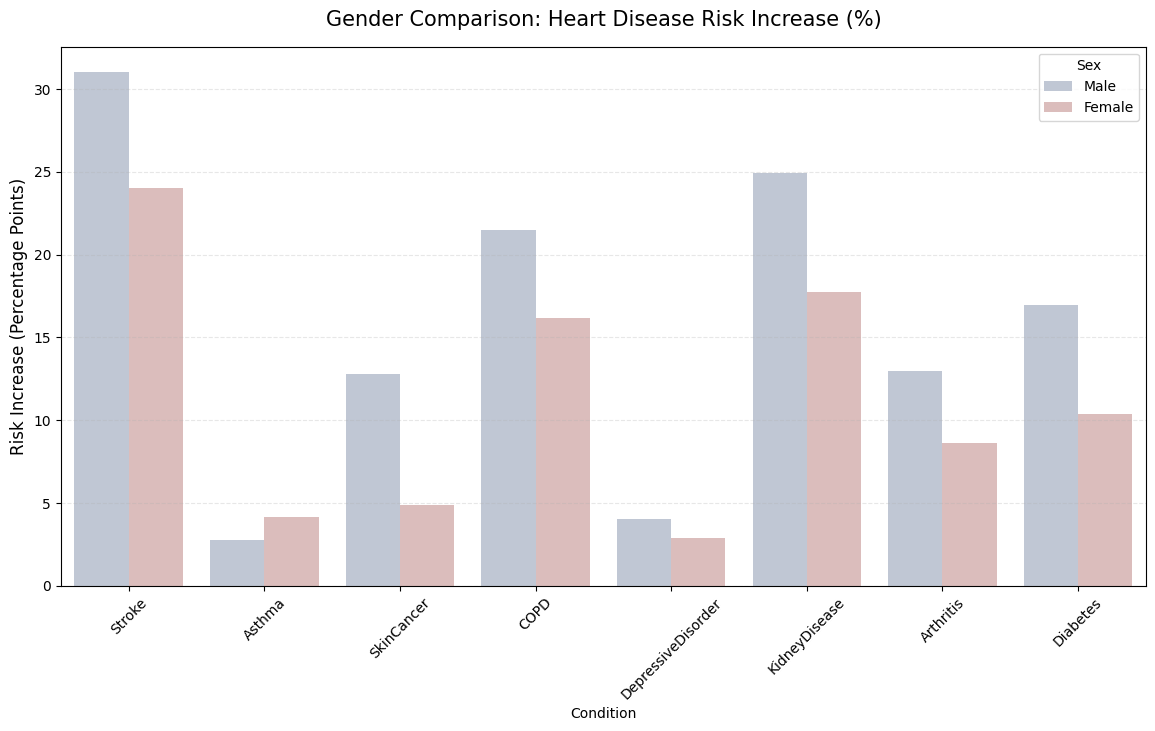

In [86]:
gender_results = []

# Loop through Male and Female
for sex in ['Male', 'Female']:
    for col in conditions:
        # Calculate risk for those with the condition
        risk_yes = analysis_df[(analysis_df['Sex'] == sex) & (analysis_df[col] == 1)]['HadHeartDisease'].mean() * 100
        # Calculate risk for those without the condition
        risk_no = analysis_df[(analysis_df['Sex'] == sex) & (analysis_df[col] == 0)]['HadHeartDisease'].mean() * 100

        gender_results.append({
            'Condition': col.replace('Had', ''),
            'Sex': sex,
            'Risk_Jump': risk_yes - risk_no
        })

gender_df = pd.DataFrame(gender_results)

plt.figure(figsize=(14, 7))
sns.barplot(data=gender_df, x='Condition', y='Risk_Jump', hue='Sex', palette='vlag')

plt.title('Gender Comparison: Heart Disease Risk Increase (%)', fontsize=15, pad=15)
plt.ylabel('Risk Increase (Percentage Points)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

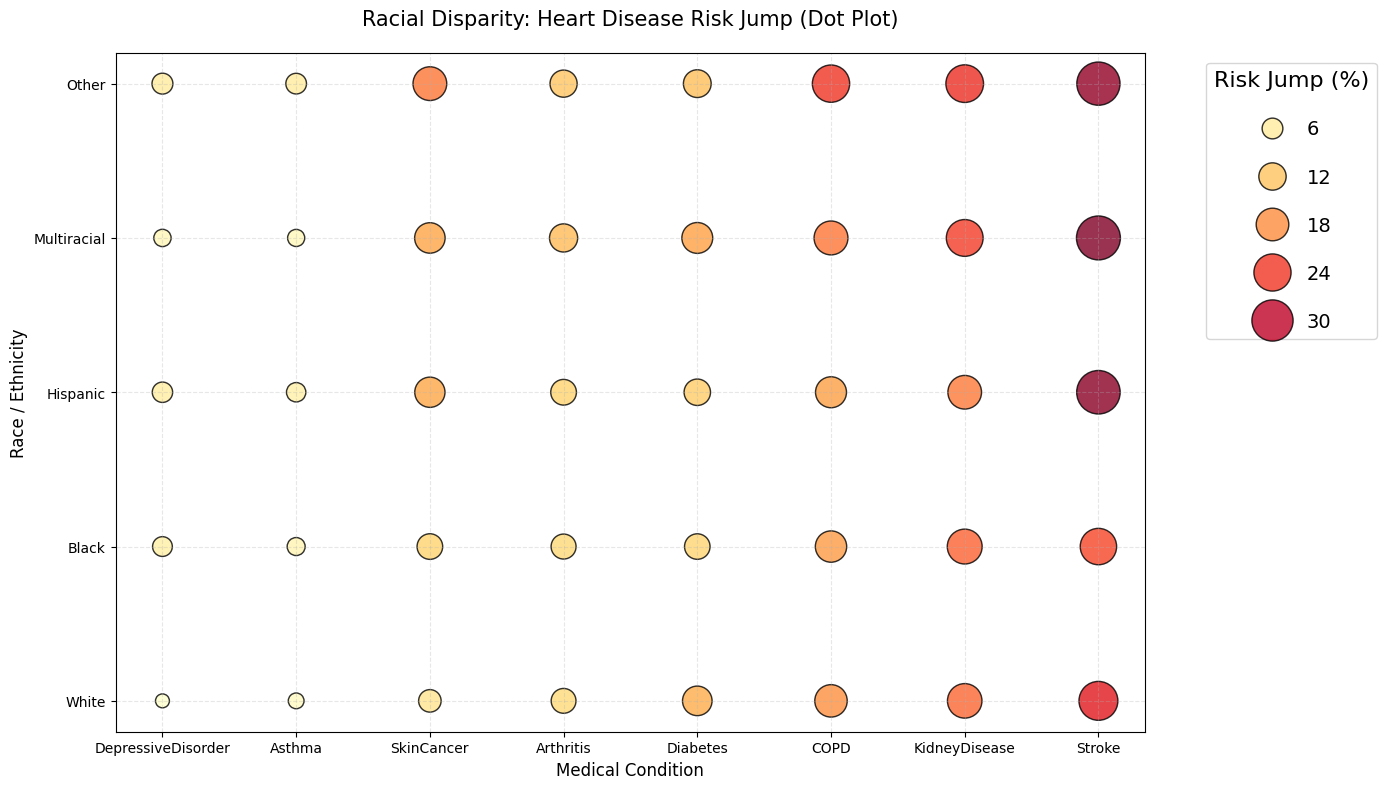

In [87]:
race_results = []
active_races = ['White', 'Black', 'Hispanic', 'Multiracial', 'Other']

# Loop through each race in the list
for race in active_races:
    for col in conditions:
        # Those who do have the medical condition
        risk_yes = analysis_df[(analysis_df['Race'] == race) & (analysis_df[col] == 1)]['HadHeartDisease'].mean() * 100
        # Those who don't
        risk_no = analysis_df[(analysis_df['Race'] == race) & (analysis_df[col] == 0)]['HadHeartDisease'].mean() * 100

        race_results.append({
            'Race': race,
            'Condition': col.replace('Had', ''),
            'Risk_Jump': risk_yes - risk_no
        })

dot_df = pd.DataFrame(race_results)

# Set the custom order for Conditions
condition_order = ['DepressiveDisorder', 'Asthma', 'SkinCancer', 'Arthritis', 'Diabetes', 'COPD', 'KidneyDisease', 'Stroke']
dot_df['Condition'] = pd.Categorical(dot_df['Condition'], categories=condition_order, ordered=True)

# Set the custom order for race
race_order = ['Other', 'Multiracial', 'Hispanic', 'Black', 'White']
dot_df['Race'] = pd.Categorical(dot_df['Race'], categories=race_order, ordered=True)

# Plotting
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=dot_df,
    x='Condition',
    y='Race',
    size='Risk_Jump',
    hue='Risk_Jump',
    palette='YlOrRd',
    sizes=(100, 1000),
    edgecolor='black',
    alpha=0.8
)

# Formatting
plt.title('Racial Disparity: Heart Disease Risk Jump (Dot Plot)', fontsize=15, pad=20)
plt.xlabel('Medical Condition', fontsize=12)
plt.ylabel('Race / Ethnicity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Adjust legend
plt.legend(
    title='Risk Jump (%)',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=14,
    title_fontsize=16,
    labelspacing=1.5
)
plt.tight_layout()

plt.show()